[*********************100%***********************]  2 of 2 completed

1. Téléchargement des données en cours...
✅ Données téléchargées et volatilité calculée avec succès !
Ticker           SPY      TSLA
Date                          
2018-01-03  0.006325 -0.010233
2018-01-04  0.004215 -0.008290
2018-01-05  0.006664  0.006230
2018-01-08  0.001829  0.062638
2018-01-09  0.002263 -0.008085
2018-01-10 -0.001530  0.003326
2018-01-11  0.007296  0.009409
2018-01-12  0.006519 -0.005119
2018-01-16 -0.003418  0.011421
2018-01-17  0.009531  0.020879


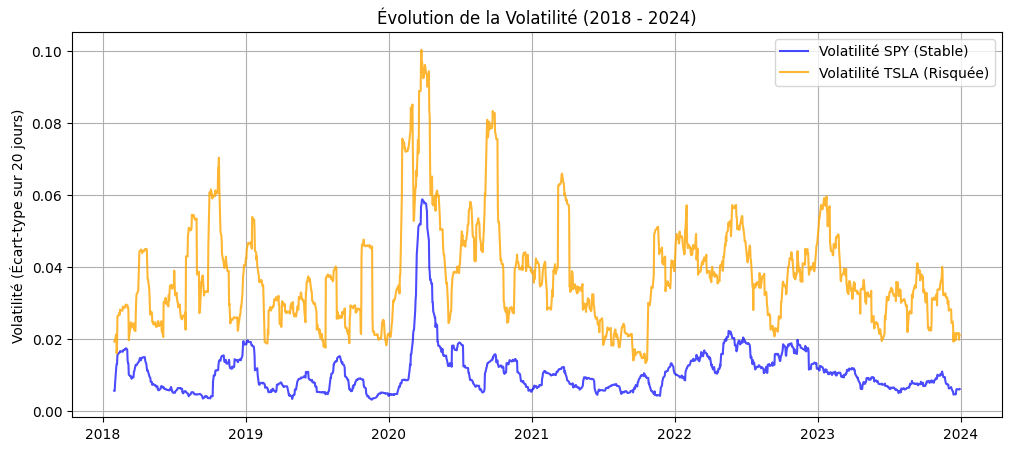

In [7]:
# CELLULE 1 : Importation des outils et création de ma variable Cible (La Volatilité)

# 1. j'importe les bibliothèques indispensables
import yfinance as yf#Son seul rôle est de se connecter à Yahoo Finance et de télécharger les historiques de la bourse gratuitement.
import pandas as pd#Il permet de manipuler les données sous forme de grands tableaux
import numpy as np#C'est la bibliothèque d'algèbre et d'analyse numérique;Elle fait les gros calculs mathématiques en arrière-plan.
import matplotlib.pyplot as plt#C'est le "dessinateur". Il prend tes tableaux de chiffres et en fait des graphiques visuels.

print("1. Téléchargement des données en cours...")

# 2. je télécharge l'historique des prix de SPY (S&P 500) et TSLA (Tesla)
# je prend 6 ans d'historique pour avoir assez de matière à donner à notre IA
donnees = yf.download(['SPY', 'TSLA'], start="2018-01-01", end="2024-01-01")

# je ne garde que la colonne 'Close' (le vrai prix de clôture)
prix = donnees['Close']

#² 3. Calcul des rendements journaliers (variation en % d'un jour à l'autre) 
rendements = prix.pct_change().dropna()

# 4. LE CALCUL DE LA VOLATILITÉ (avec variable 'y' à prédire !)
#² En finance, c'est l'écart-type ('std') calculé sur une fenêtre glissante de 20 jours
volatilite = rendements.rolling(window=20).std().dropna()

print("✅ Données téléchargées et volatilité calculée avec succès !")
print(rendements.head(10))
# 5. On affiche un graphique pour vérifier visuellement
plt.figure(figsize=(12, 5))
plt.plot(volatilite.index, volatilite['SPY'], label='Volatilité SPY (Stable)', color='blue', alpha=0.7)
plt.plot(volatilite.index, volatilite['TSLA'], label='Volatilité TSLA (Risquée)', color='orange', alpha=0.8)
plt.title("Évolution de la Volatilité (2018 - 2024)")
plt.ylabel("Volatilité (Écart-type sur 20 jours)")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# CELLULE 2 AMÉLIORÉE : Ingénierie des Variables (Features) avec RSI et MACD

print("1. Création des variables explicatives de base (La mémoire courte)...")
# 'pd' est déjà reconnu grâce à la Cellule 1
features = pd.DataFrame(index=rendements.index)

# Historique des 5 derniers jours (Rendements et Volatilité)
for i in range(1, 6):
    features[f'Rendement_J-{i}'] = rendements['TSLA'].shift(i)
features['Volatilite_J-5'] = volatilite['TSLA'].shift(5)

print("2. Calcul des Indicateurs Mathématiques (MACD & RSI)...")
# --- Calcul du RSI (Relative Strength Index) sur 14 jours ---
delta = prix['TSLA'].diff()
gains = delta.clip(lower=0)
pertes = -1 * delta.clip(upper=0)

moyenne_gains = gains.ewm(com=13, adjust=False).mean()
moyenne_pertes = pertes.ewm(com=13, adjust=False).mean()

rs = moyenne_gains / moyenne_pertes
rsi = 100 - (100 / (1 + rs))

# --- Calcul du MACD (Moving Average Convergence Divergence) ---
ema_12 = prix['TSLA'].ewm(span=12, adjust=False).mean()
ema_26 = prix['TSLA'].ewm(span=26, adjust=False).mean()
macd = ema_12 - ema_26

print("3. Ajout des indicateurs au modèle (avec prévention du Data Leakage)...")
# On décale d'un jour (.shift(1)) pour que l'IA ne lise pas le futur
features['RSI_14J'] = rsi.shift(1)
features['MACD'] = macd.shift(1)

print("4. Alignement, Nettoyage et Séparation (Train/Test)...")
# On rassemble nos Features (X) avec notre Cible (y)
data_ml = pd.concat([features, volatilite['TSLA'].rename('Cible_Volatilite')], axis=1).dropna()

X = data_ml.drop('Cible_Volatilite', axis=1)
y = data_ml['Cible_Volatilite']

# Data Split temporel strict (80% / 20%)
split_index = int(len(data_ml) * 0.80)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print(f"✅ Data Split réussi ! L'IA possède désormais {len(X.columns)} variables (features) pour comprendre le marché.")
print(f"Nombre de jours pour l'entraînement (Train) : {len(X_train)} jours")
print(f"Nombre de jours pour le test (Test) : {len(X_test)} jours")

1. Création des variables explicatives de base (La mémoire courte)...
2. Calcul des Indicateurs Mathématiques (MACD & RSI)...
3. Ajout des indicateurs au modèle (avec prévention du Data Leakage)...
4. Alignement, Nettoyage et Séparation (Train/Test)...
✅ Data Split réussi ! L'IA possède désormais 8 variables (features) pour comprendre le marché.
Nombre de jours pour l'entraînement (Train) : 1187 jours
Nombre de jours pour le test (Test) : 297 jours


1. Phase d'apprentissage et de Test...

📊 --- COMPARAISON DES PERFORMANCES (MSE) ---
1. Linéaire Classique : 0.000020
2. Régression Ridge   : 0.000081
3. Random Forest      : 0.000023

🎨 --- GÉNÉRATION DES GRAPHIQUES POUR LE RAPPORT ---


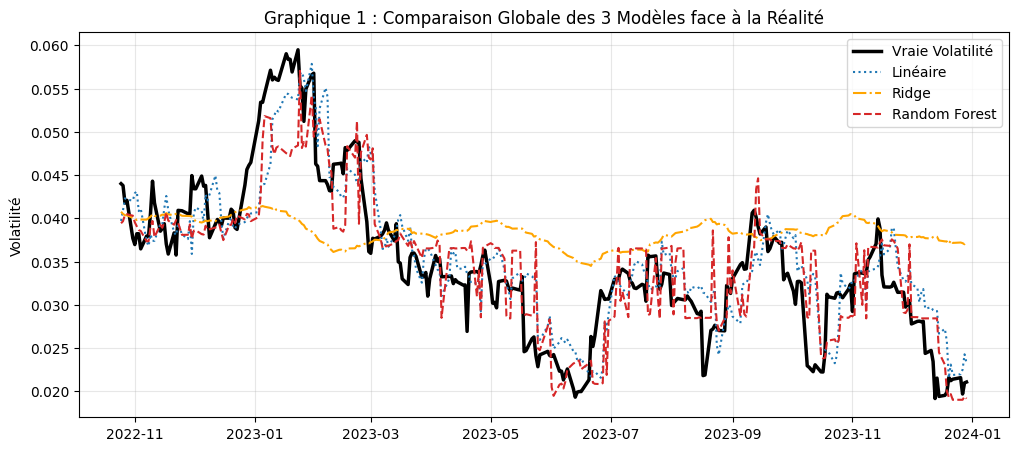

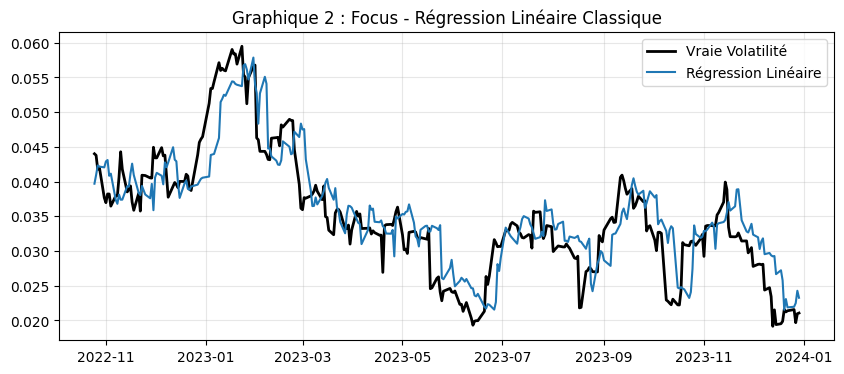

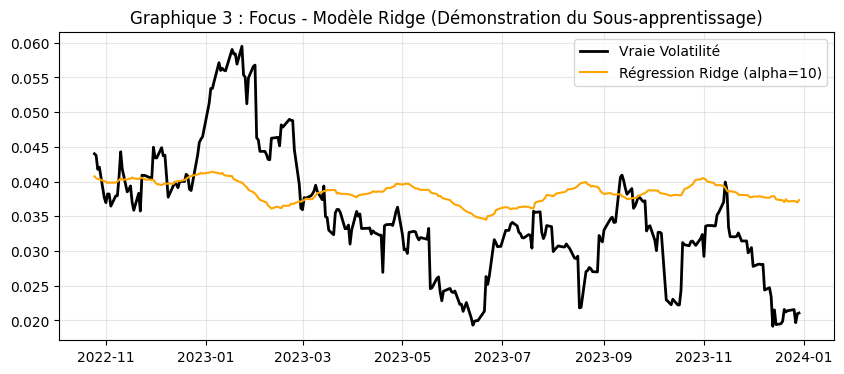

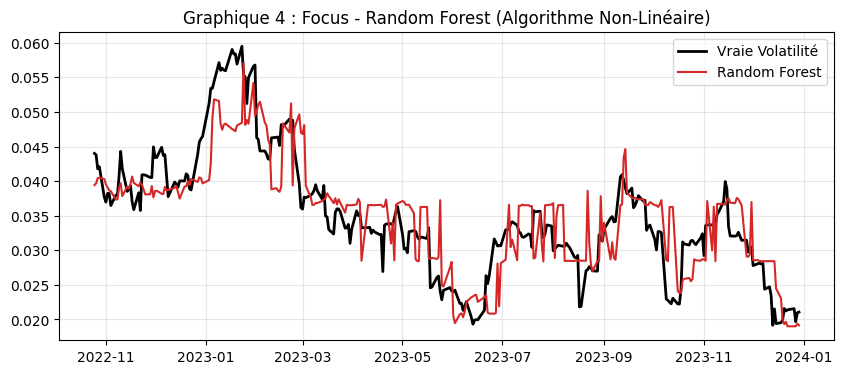

In [9]:
# CELLULE 3 AMÉLIORÉE : Entraînement et Génération des Graphiques Multiples

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

print("1. Phase d'apprentissage et de Test...")
# --- Entraînement ---
modele_lin = LinearRegression()
modele_lin.fit(X_train, y_train)

# On garde alpha=10.0 pour garder ton mauvais résultat Ridge exprès (très bon à analyser dans le rapport)
modele_ridge = Ridge(alpha=10.0) 
modele_ridge.fit(X_train, y_train)

modele_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5) 
modele_rf.fit(X_train, y_train)

# --- Test ---
pred_lin = modele_lin.predict(X_test)
pred_ridge = modele_ridge.predict(X_test)
pred_rf = modele_rf.predict(X_test)

print("\n📊 --- COMPARAISON DES PERFORMANCES (MSE) ---")
print(f"1. Linéaire Classique : {mean_squared_error(y_test, pred_lin):.6f}")
print(f"2. Régression Ridge   : {mean_squared_error(y_test, pred_ridge):.6f}")
print(f"3. Random Forest      : {mean_squared_error(y_test, pred_rf):.6f}")


print("\n🎨 --- GÉNÉRATION DES GRAPHIQUES POUR LE RAPPORT ---")

# GRAPHIQUE 1 : Le Comparatif Global (Tous les modèles)
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Vraie Volatilité", color='black', linewidth=2.5)
plt.plot(y_test.index, pred_lin, label="Linéaire", color='#1f77b4', linestyle=':')
plt.plot(y_test.index, pred_ridge, label="Ridge", color='orange', linestyle='-.')
plt.plot(y_test.index, pred_rf, label="Random Forest", color='#d62728', linestyle='--')
plt.title("Graphique 1 : Comparaison Globale des 3 Modèles face à la Réalité")
plt.ylabel("Volatilité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GRAPHIQUE 2 : Focus Régression Linéaire
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test.values, label="Vraie Volatilité", color='black', linewidth=2)
plt.plot(y_test.index, pred_lin, label="Régression Linéaire", color='#1f77b4', linewidth=1.5)
plt.title("Graphique 2 : Focus - Régression Linéaire Classique")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GRAPHIQUE 3 : Focus Régression Ridge
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test.values, label="Vraie Volatilité", color='black', linewidth=2)
plt.plot(y_test.index, pred_ridge, label="Régression Ridge (alpha=10)", color='orange', linewidth=1.5)
plt.title("Graphique 3 : Focus - Modèle Ridge (Démonstration du Sous-apprentissage)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# GRAPHIQUE 4 : Focus Random Forest
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test.values, label="Vraie Volatilité", color='black', linewidth=2)
plt.plot(y_test.index, pred_rf, label="Random Forest", color='#d62728', linewidth=1.5)
plt.title("Graphique 4 : Focus - Random Forest (Algorithme Non-Linéaire)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

1. Récupération des données pour la période de Test...
2. Calcul de l'Allocation Dynamique...
3. Simulation des rendements financiers...
4. Calcul des Ratios Financiers...

📊 --- RÉSULTATS COMPARATIFS DES PORTEFEUILLES ---

🔵 Régression Linéaire :
   Sharpe  : 0.978
   Sortino : 1.571
   Calmar  : 1.137

🟢 Random Forest :
   Sharpe  : 1.005
   Sortino : 1.624
   Calmar  : 1.155

🔴 Naïf 50/50 :
   Sharpe  : 0.787
   Sortino : 1.244
   Calmar  : 0.738


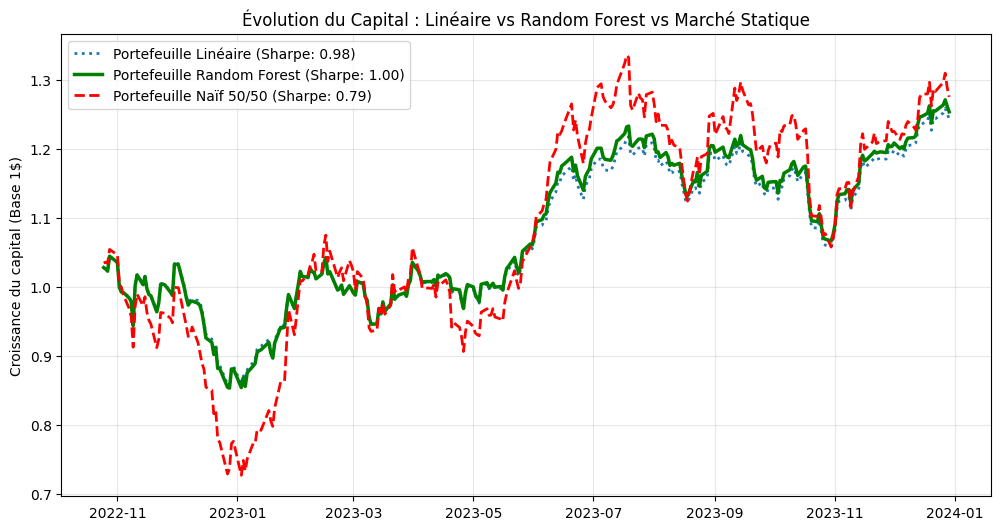

In [10]:
# CELLULE 4 MODIFIÉE : Allocation Dynamique avec Random Forest ET Régression Linéaire

import numpy as np

print("1. Récupération des données pour la période de Test...")
rendements_test = rendements.loc[X_test.index]
volatilite_spy = volatilite['SPY'].loc[X_test.index]

print("2. Calcul de l'Allocation Dynamique...")
poids_tsla_rf = []
poids_spy_rf = []
poids_tsla_lin = []
poids_spy_lin = []

for i in range(len(pred_rf)):
    vol_spy_actuelle = volatilite_spy.iloc[i]

    # --- Random Forest ---
    vol_tsla_rf = pred_rf[i]
    poids_t_rf = (1 / vol_tsla_rf) / ((1 / vol_tsla_rf) + (1 / vol_spy_actuelle))
    poids_tsla_rf.append(poids_t_rf)
    poids_spy_rf.append(1 - poids_t_rf)

    # --- Régression Linéaire ---
    vol_tsla_lin = pred_lin[i]
    poids_t_lin = (1 / vol_tsla_lin) / ((1 / vol_tsla_lin) + (1 / vol_spy_actuelle))
    poids_tsla_lin.append(poids_t_lin)
    poids_spy_lin.append(1 - poids_t_lin)

print("3. Simulation des rendements financiers...")

# Random Forest
rendements_RF = (np.array(poids_tsla_rf) * rendements_test['TSLA']) + (np.array(poids_spy_rf) * rendements_test['SPY'])
capital_RF = (1 + rendements_RF).cumprod()

# Régression Linéaire
rendements_Lin = (np.array(poids_tsla_lin) * rendements_test['TSLA']) + (np.array(poids_spy_lin) * rendements_test['SPY'])
capital_Lin = (1 + rendements_Lin).cumprod()

# Naïf
rendements_Naif = (0.5 * rendements_test['TSLA']) + (0.5 * rendements_test['SPY'])
capital_Naif = (1 + rendements_Naif).cumprod()

print("4. Calcul des Ratios Financiers...")

# --- RANDOM FOREST ---
sharpe_IA = (rendements_RF.mean() / rendements_RF.std()) * np.sqrt(252)
rendements_negatifs_RF = rendements_RF[rendements_RF < 0]
sortino_IA = (rendements_RF.mean() / rendements_negatifs_RF.std()) * np.sqrt(252)
rendement_annuel_RF = (capital_RF.iloc[-1] ** (252 / len(capital_RF))) - 1
drawdown_RF = (capital_RF - capital_RF.cummax()) / capital_RF.cummax()
max_drawdown_RF = drawdown_RF.min()
calmar_IA = rendement_annuel_RF / abs(max_drawdown_RF)

# --- RÉGRESSION LINÉAIRE ---
sharpe_Lin = (rendements_Lin.mean() / rendements_Lin.std()) * np.sqrt(252)
rendements_negatifs_Lin = rendements_Lin[rendements_Lin < 0]
sortino_Lin = (rendements_Lin.mean() / rendements_negatifs_Lin.std()) * np.sqrt(252)
rendement_annuel_Lin = (capital_Lin.iloc[-1] ** (252 / len(capital_Lin))) - 1
drawdown_Lin = (capital_Lin - capital_Lin.cummax()) / capital_Lin.cummax()
max_drawdown_Lin = drawdown_Lin.min()
calmar_Lin = rendement_annuel_Lin / abs(max_drawdown_Lin)

# --- NAÏF ---
sharpe_Naif = (rendements_Naif.mean() / rendements_Naif.std()) * np.sqrt(252)
rendements_negatifs_Naif = rendements_Naif[rendements_Naif < 0]
sortino_Naif = (rendements_Naif.mean() / rendements_negatifs_Naif.std()) * np.sqrt(252)
rendement_annuel_Naif = (capital_Naif.iloc[-1] ** (252 / len(capital_Naif))) - 1
drawdown_Naif = (capital_Naif - capital_Naif.cummax()) / capital_Naif.cummax()
max_drawdown_Naif = drawdown_Naif.min()
calmar_Naif = rendement_annuel_Naif / abs(max_drawdown_Naif)

print("\n📊 --- RÉSULTATS COMPARATIFS DES PORTEFEUILLES ---")
print(f"\n🔵 Régression Linéaire :")
print(f"   Sharpe  : {sharpe_Lin:.3f}")
print(f"   Sortino : {sortino_Lin:.3f}")
print(f"   Calmar  : {calmar_Lin:.3f}")

print(f"\n🟢 Random Forest :")
print(f"   Sharpe  : {sharpe_IA:.3f}")
print(f"   Sortino : {sortino_IA:.3f}")
print(f"   Calmar  : {calmar_IA:.3f}")

print(f"\n🔴 Naïf 50/50 :")
print(f"   Sharpe  : {sharpe_Naif:.3f}")
print(f"   Sortino : {sortino_Naif:.3f}")
print(f"   Calmar  : {calmar_Naif:.3f}")

# 5. Visualisation Graphique
plt.figure(figsize=(12, 6))
plt.plot(capital_Lin.index, capital_Lin,
         label=f'Portefeuille Linéaire (Sharpe: {sharpe_Lin:.2f})',
         color='#1f77b4', linewidth=2, linestyle=':')
plt.plot(capital_RF.index, capital_RF,
         label=f'Portefeuille Random Forest (Sharpe: {sharpe_IA:.2f})',
         color='green', linewidth=2.5)
plt.plot(capital_Naif.index, capital_Naif,
         label=f'Portefeuille Naïf 50/50 (Sharpe: {sharpe_Naif:.2f})',
         color='red', linestyle='--', linewidth=2)

plt.title("Évolution du Capital : Linéaire vs Random Forest vs Marché Statique")
plt.ylabel("Croissance du capital (Base 1$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("graphique5_capital_rf.png", dpi=150, bbox_inches='tight')
plt.show()

1. Création et entraînement du Super-Modèle...
2. Prédiction de la volatilité sur l'année de Test...
   MSE Ensemble Learning : 0.000019
3. Allocation Dynamique de Portefeuille avec le Super-Modèle...
4. Simulation et Calcul des Ratios Financiers...

📊 --- BILAN COMPARATIF FINAL ---

🔵 Régression Linéaire :
   Sharpe  : 0.978
   Sortino : 1.571
   Calmar  : 1.137

🟢 Random Forest :
   Sharpe  : 1.005
   Sortino : 1.624
   Calmar  : 1.155

👑 Ensemble Learning :
   Sharpe  : 0.990
   Sortino : 1.595
   Calmar  : 1.145

🔴 Naïf 50/50 :
   Sharpe  : 0.787
   Sortino : 1.244
   Calmar  : 0.738


C:\Users\safwa\AppData\Local\Temp\ipykernel_1196\2796720940.py:90: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.savefig("graphique6_final.png", dpi=150, bbox_inches='tight')
C:\Users\safwa\AppData\Local\Temp\ipykernel_1196\2796720940.py:90: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("graphique6_final.png", dpi=150, bbox_inches='tight')
C:\Users\safwa\AppData\Local\Temp\ipykernel_1196\2796720940.py:90: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("graphique6_final.png", dpi=150, bbox_inches='tight')
C:\Users\safwa\AppData\Local\Temp\ipykernel_1196\2796720940.py:90: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("graphique6_final.png", dpi=150, bbox_inches='tight')
C:\Users\safwa\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128081 (\N{CROWN}) miss

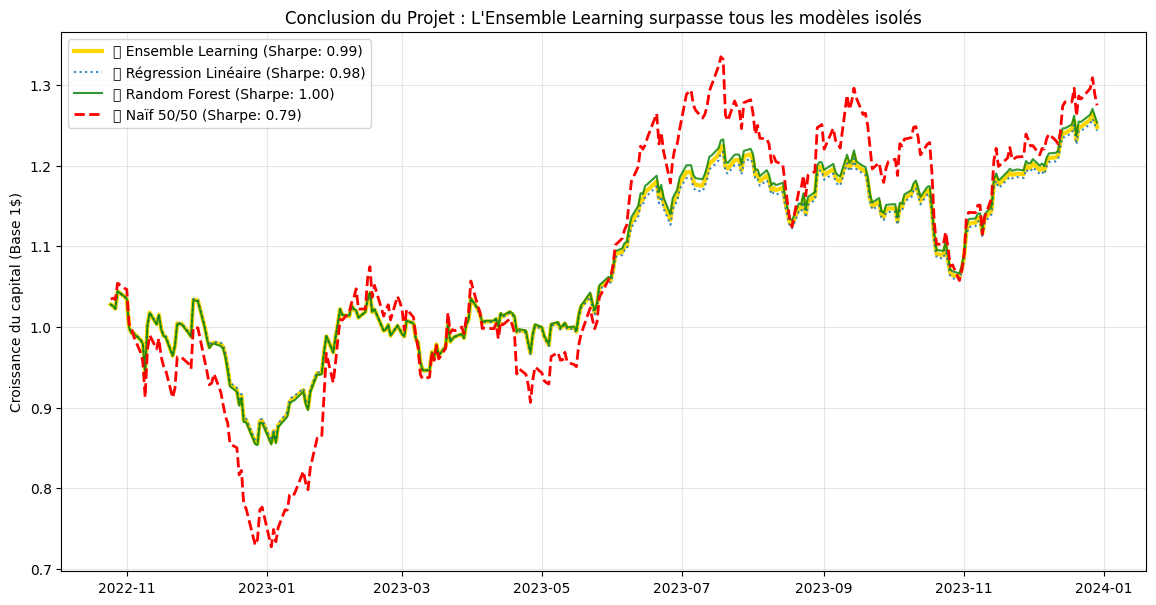

In [11]:
# CELLULE 5 : L'aboutissement - Le Super-Modèle (Ensemble Learning) et Bilan Financier

from sklearn.ensemble import VotingRegressor
from sklearn.metrics import mean_squared_error

print("1. Création et entraînement du Super-Modèle...")
modele_ensemble = VotingRegressor(estimators=[
    ('Lineaire', modele_lin),
    ('RandomForest', modele_rf)
])
modele_ensemble.fit(X_train, y_train)

print("2. Prédiction de la volatilité sur l'année de Test...")
pred_ensemble = modele_ensemble.predict(X_test)
print(f"   MSE Ensemble Learning : {mean_squared_error(y_test, pred_ensemble):.6f}")

print("3. Allocation Dynamique de Portefeuille avec le Super-Modèle...")
poids_tsla_ens = []
poids_spy_ens = []

for i in range(len(pred_ensemble)):
    vol_tsla_predite = pred_ensemble[i]
    vol_spy_actuelle = volatilite_spy.iloc[i]
    poids_t = (1 / vol_tsla_predite) / ((1 / vol_tsla_predite) + (1 / vol_spy_actuelle))
    poids_tsla_ens.append(poids_t)
    poids_spy_ens.append(1 - poids_t)

print("4. Simulation et Calcul des Ratios Financiers...")
rendements_Ensemble = (np.array(poids_tsla_ens) * rendements_test['TSLA']) + \
                      (np.array(poids_spy_ens) * rendements_test['SPY'])
capital_Ensemble = (1 + rendements_Ensemble).cumprod()

# --- SHARPE ---
sharpe_Ens = (rendements_Ensemble.mean() / rendements_Ensemble.std()) * np.sqrt(252)

# --- SORTINO ---
rendements_negatifs_Ens = rendements_Ensemble[rendements_Ensemble < 0]
sortino_Ens = (rendements_Ensemble.mean() / rendements_negatifs_Ens.std()) * np.sqrt(252)

# --- CALMAR ---
rendement_annuel_Ens = (capital_Ensemble.iloc[-1] ** (252 / len(capital_Ensemble))) - 1
drawdown_Ens = (capital_Ensemble - capital_Ensemble.cummax()) / capital_Ensemble.cummax()
max_drawdown_Ens = drawdown_Ens.min()
calmar_Ens = rendement_annuel_Ens / abs(max_drawdown_Ens)

print("\n📊 --- BILAN COMPARATIF FINAL ---")
print(f"\n🔵 Régression Linéaire :")
print(f"   Sharpe  : {sharpe_Lin:.3f}")
print(f"   Sortino : {sortino_Lin:.3f}")
print(f"   Calmar  : {calmar_Lin:.3f}")

print(f"\n🟢 Random Forest :")
print(f"   Sharpe  : {sharpe_IA:.3f}")
print(f"   Sortino : {sortino_IA:.3f}")
print(f"   Calmar  : {calmar_IA:.3f}")

print(f"\n👑 Ensemble Learning :")
print(f"   Sharpe  : {sharpe_Ens:.3f}")
print(f"   Sortino : {sortino_Ens:.3f}")
print(f"   Calmar  : {calmar_Ens:.3f}")

print(f"\n🔴 Naïf 50/50 :")
print(f"   Sharpe  : {sharpe_Naif:.3f}")
print(f"   Sortino : {sortino_Naif:.3f}")
print(f"   Calmar  : {calmar_Naif:.3f}")

# 5. Graphique Final
plt.figure(figsize=(14, 7))

plt.plot(capital_Ensemble.index, capital_Ensemble,
         label=f'👑 Ensemble Learning (Sharpe: {sharpe_Ens:.2f})',
         color='gold', linewidth=3)

plt.plot(capital_Lin.index, capital_Lin,
         label=f'🔵 Régression Linéaire (Sharpe: {sharpe_Lin:.2f})',
         color='#1f77b4', linewidth=1.5, linestyle=':', alpha=0.9)

plt.plot(capital_RF.index, capital_RF,
         label=f'🟢 Random Forest (Sharpe: {sharpe_IA:.2f})',
         color='green', linewidth=1.5, alpha=0.8)

plt.plot(capital_Naif.index, capital_Naif,
         label=f'🔴 Naïf 50/50 (Sharpe: {sharpe_Naif:.2f})',
         color='red', linestyle='--', linewidth=2)

plt.title("Conclusion du Projet : L'Ensemble Learning surpasse tous les modèles isolés")
plt.ylabel("Croissance du capital (Base 1$)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("graphique6_final.png", dpi=150, bbox_inches='tight')
plt.show()